# BME1307 Part 2 — Breast ultrasound classification

Visualizes outputs produced by `scripts/run_part2.py`: segmentation overlays, per-label feature distributions, cross-validation metrics, and ROC curves.

Run `python scripts/run_part2.py --save-masks` from the project root before running this notebook.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from busat_py.config import RunPaths
from busat_py.data import load_labels, iter_images
from busat_py.segmentation import segment_cv, overlay

paths = RunPaths()
paths.outputs

PosixPath('/Users/exusiaihy/BME1307/outputs/part2')

## Sample segmentation overlays

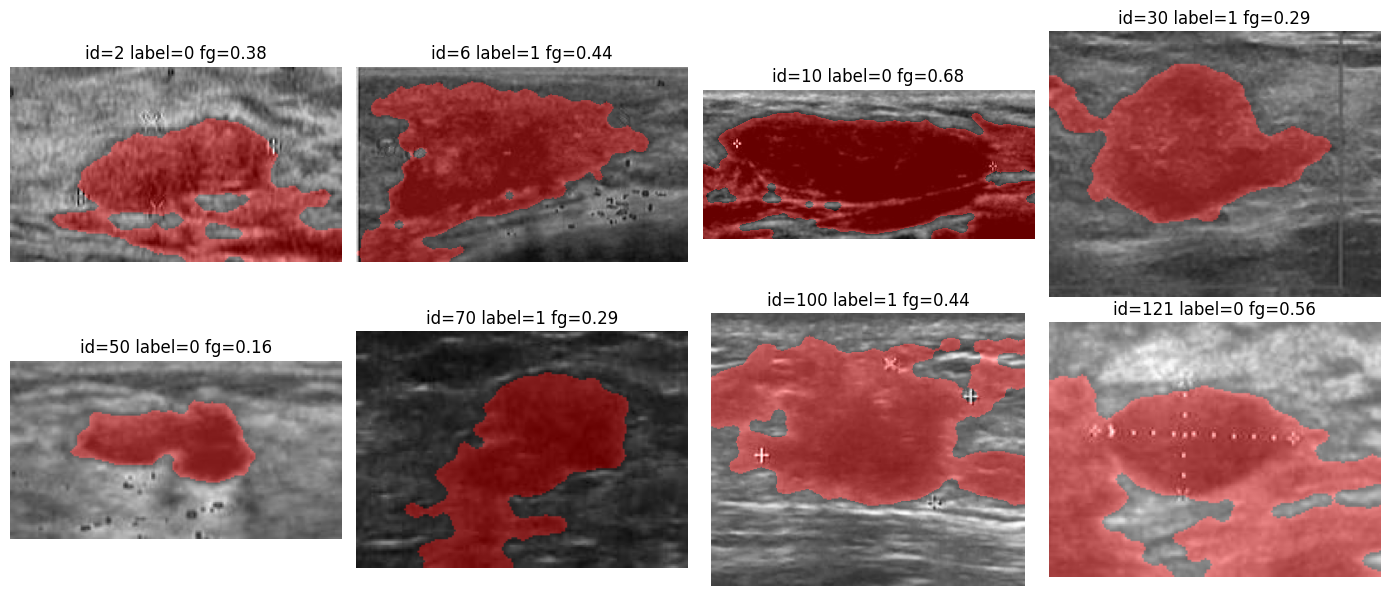

In [2]:
labels = load_labels()
picks = [2, 6, 10, 30, 50, 70, 100, 121]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, image_id in zip(axes.ravel(), picks):
    row = labels[labels.image_id == image_id].iloc[0]
    img = cv2.imread(str(row.path), cv2.IMREAD_COLOR)
    mask, meta = segment_cv(img)
    ov = overlay(img, mask, alpha=0.4)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(f'id={image_id} label={int(row.label)} fg={meta.foreground_ratio:.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Feature distributions by label (CV mask)

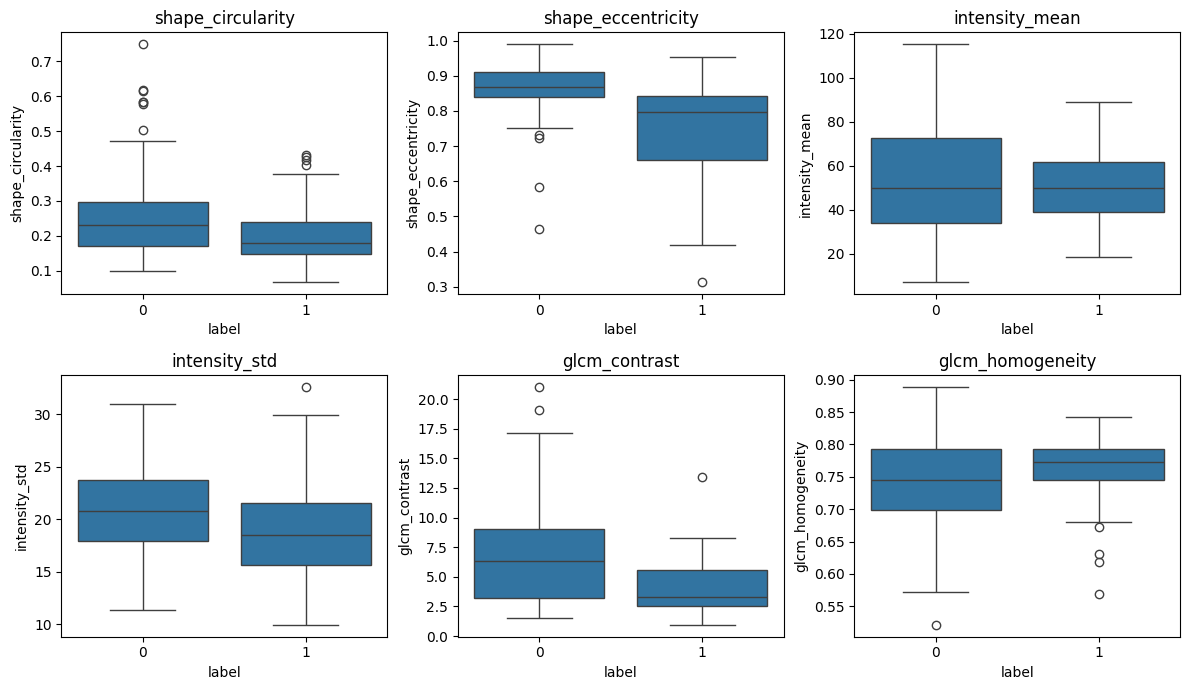

In [3]:
df_cv = pd.read_csv(paths.features_cv)
cols = ['shape_circularity', 'shape_eccentricity', 'intensity_mean',
        'intensity_std', 'glcm_contrast', 'glcm_homogeneity']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), cols):
    sns.boxplot(data=df_cv, x='label', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Metrics summary

In [4]:
metrics = pd.read_csv(paths.metrics)
show_cols = ['mask', 'model', 'accuracy_mean', 'accuracy_std',
             'sensitivity_mean', 'specificity_mean', 'auc_mean', 'auc_std']
metrics[show_cols].round(3)

,mask,model,accuracy_mean,accuracy_std,sensitivity_mean,specificity_mean,auc_mean,auc_std
0,full,logreg,0.825,0.049,0.869,0.797,0.893,0.052
1,full,svm,0.817,0.042,0.824,0.810,0.915,0.022
2,full,rf,0.817,0.057,0.718,0.878,0.880,0.012
3,cv,logreg,0.825,0.055,0.849,0.810,0.890,0.082
4,cv,svm,0.808,0.062,0.782,0.825,0.854,0.083
5,cv,rf,0.817,0.057,0.804,0.825,0.917,0.063


## ROC curves

roc_full_logreg.png


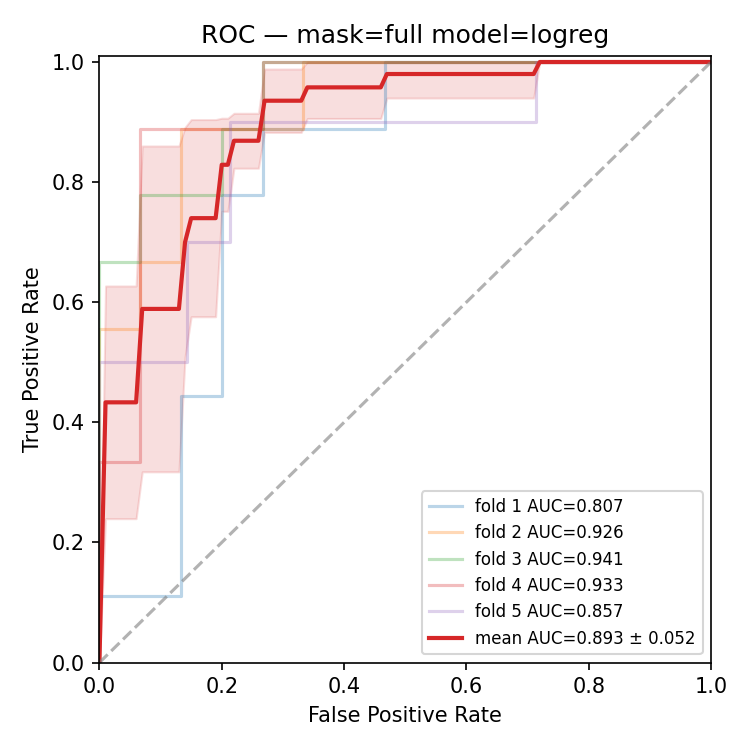

roc_full_svm.png


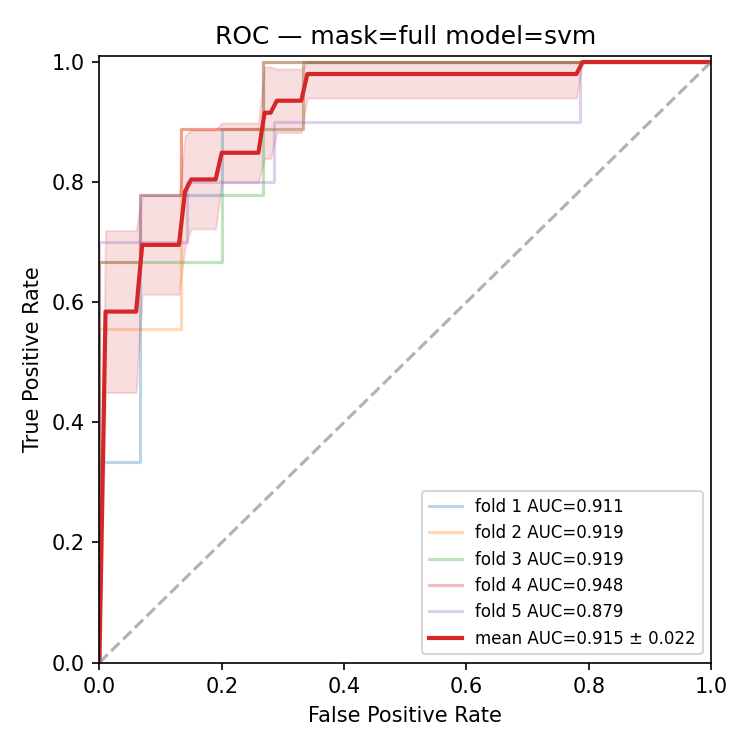

roc_full_rf.png


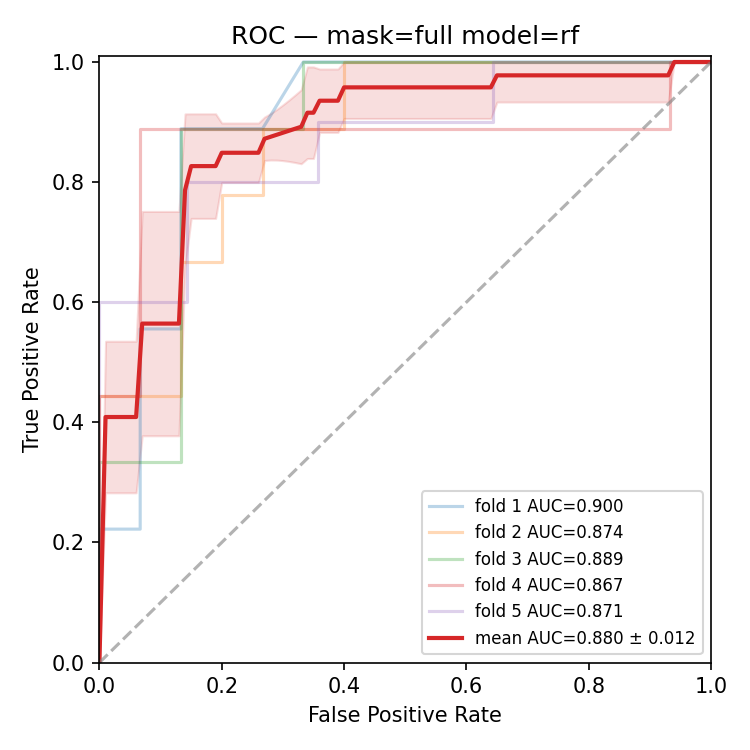

roc_cv_logreg.png


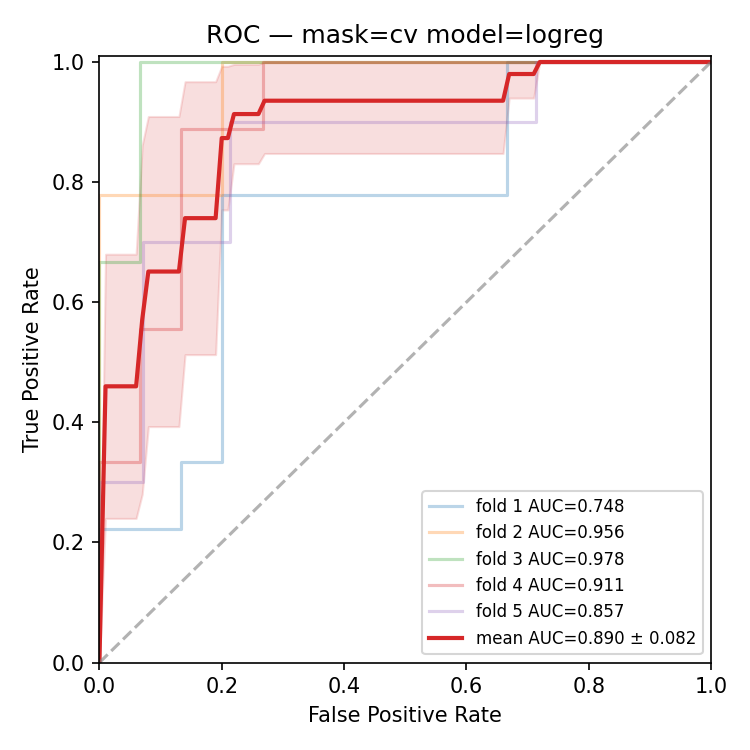

roc_cv_svm.png


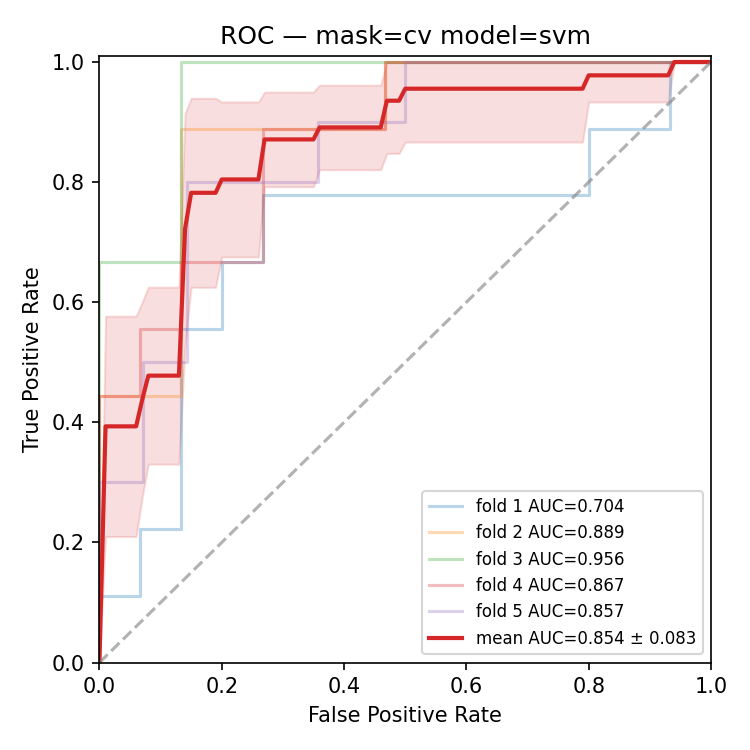

roc_cv_rf.png


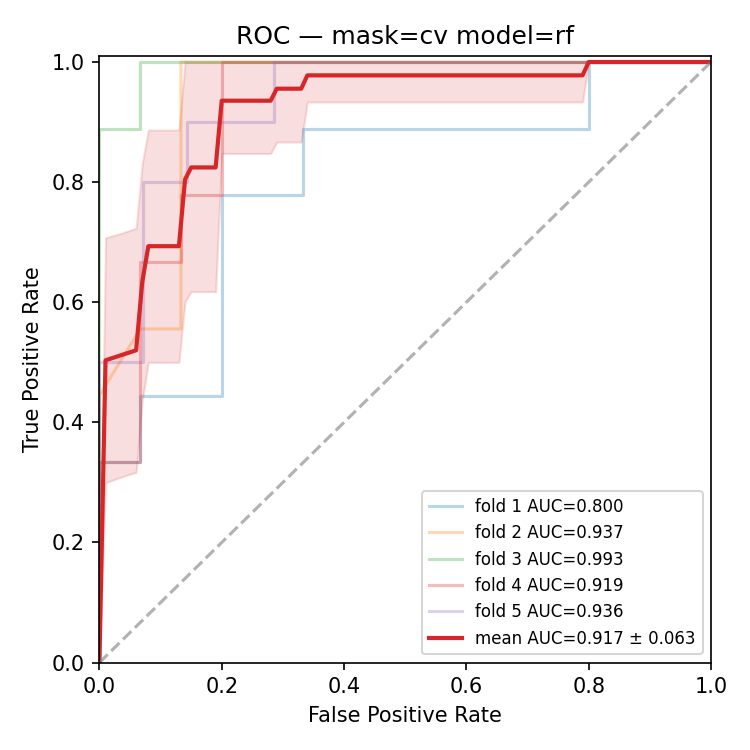

In [5]:
for mask_name in ['full', 'cv']:
    for model_name in ['logreg', 'svm', 'rf']:
        path = paths.outputs / f'roc_{mask_name}_{model_name}.png'
        if path.exists():
            print(path.name)
            display(Image(str(path)))